# Vitamin Deficiency Prediction
This notebook contains a complete workflow for building a vitamin deficiency prediction model.

## 1. Import Required Libraries

In [763]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import *
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import KFold


## 2. Load Dataset

In [764]:
DATA_PATH = 'Data/data.csv'
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
df.head()

Shape: (3500, 21)


,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,vitamin_c_percent_rda,vitamin_d_percent_rda,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,vitamin_deficiency
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,147.3,152.88,97.5,102.5,188.9,108.3,97.4,0,NaN,0.0000
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,57.5,32.76,82.7,62.6,51.0,42.6,102.5,1,bone_pain,0.8440
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,152.1,94.99,169.3,136.2,116.6,136.3,86.4,2,dry_skin;night_blindness,0.0040
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,51.0,51.48,85.7,31.8,66.5,76.5,60.8,2,numbness_tingling;memory_problems,0.7724
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,111.5,62.90,155.6,72.6,124.9,69.4,71.9,0,NaN,0.3720


## 3. Data Understanding

In [765]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3500 non-null   int64  
 1   gender                   3500 non-null   object 
 2   bmi                      3500 non-null   float64
 3   smoking_status           3500 non-null   object 
 4   alcohol_consumption      2390 non-null   object 
 5   exercise_level           3500 non-null   object 
 6   diet_type                3500 non-null   object 
 7   sun_exposure             3500 non-null   object 
 8   income_level             3500 non-null   object 
 9   latitude_region          3500 non-null   object 
 10  vitamin_a_percent_rda    3500 non-null   float64
 11  vitamin_c_percent_rda    3500 non-null   float64
 12  vitamin_d_percent_rda    3500 non-null   float64
 13  vitamin_e_percent_rda    3500 non-null   float64
 14  vitamin_b12_percent_rda 

In [766]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,3500.0,50.591714,19.279577,18.0,34.0000,50.000,67.00000,84.00
bmi,3500.0,26.098914,4.944079,15.0,22.8000,26.200,29.40000,43.90
vitamin_a_percent_rda,3500.0,90.682286,37.146999,10.0,62.3750,85.500,115.12500,219.00
vitamin_c_percent_rda,3500.0,88.571914,37.190350,10.0,60.7000,83.400,111.72500,230.50
vitamin_d_percent_rda,3500.0,72.416666,42.994453,7.0,40.6975,62.300,93.81500,275.60
vitamin_e_percent_rda,3500.0,89.676914,37.216509,10.0,61.5000,84.000,114.02500,237.60
vitamin_b12_percent_rda,3500.0,62.704571,37.441959,10.0,32.6000,55.900,84.50000,243.60
folate_percent_rda,3500.0,90.196771,37.279605,10.0,62.0000,84.600,114.75000,226.60
calcium_percent_rda,3500.0,82.364057,36.058349,10.0,55.6000,76.700,104.82500,232.70
iron_percent_rda,3500.0,76.417686,32.904281,10.0,51.7750,71.550,96.00000,211.40


In [767]:
df.dtypes

age                          int64
gender                      object
bmi                        float64
smoking_status              object
alcohol_consumption         object
exercise_level              object
diet_type                   object
sun_exposure                object
income_level                object
latitude_region             object
vitamin_a_percent_rda      float64
vitamin_c_percent_rda      float64
vitamin_d_percent_rda      float64
vitamin_e_percent_rda      float64
vitamin_b12_percent_rda    float64
folate_percent_rda         float64
calcium_percent_rda        float64
iron_percent_rda           float64
symptoms_count               int64
symptoms_list               object
vitamin_deficiency         float64
dtype: object

In [768]:
print(df['symptoms_list'].head())

0                                  NaN
1                            bone_pain
2             dry_skin;night_blindness
3    numbness_tingling;memory_problems
4                                  NaN
Name: symptoms_list, dtype: object


In [769]:
df['alcohol_consumption'] 

0            NaN
1       Moderate
2          Heavy
3          Heavy
4            NaN
          ...   
3495       Heavy
3496    Moderate
3497         NaN
3498       Heavy
3499         NaN
Name: alcohol_consumption, Length: 3500, dtype: object

In [770]:
df.nunique()

age                          67
gender                        2
bmi                         248
smoking_status                3
alcohol_consumption           2
exercise_level                4
diet_type                     4
sun_exposure                  3
income_level                  3
latitude_region               3
vitamin_a_percent_rda      1311
vitamin_c_percent_rda      1314
vitamin_d_percent_rda      2135
vitamin_e_percent_rda      1327
vitamin_b12_percent_rda    1222
folate_percent_rda         1328
calcium_percent_rda        1281
iron_percent_rda           1200
symptoms_count                9
symptoms_list               228
vitamin_deficiency         2193
dtype: int64

## 5. Preprocessing

#### 1.Feature Engineering

In [771]:
bmi_edges = [0, 18.5, 24.9, 29.9, 100] 
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_edges, labels=bmi_labels)

In [772]:
age_edges = [0, 30, 50, 120]
age_labels = ['Youth', 'Adults', 'Seniors']

df['age_group'] = pd.cut(df['age'], bins=age_edges, labels=age_labels)

In [773]:
df.drop(["age", "bmi"], axis=1, inplace=True)

#### Handle missing 

In [774]:
df_preprocessed = df.copy()

In [775]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   gender                   3500 non-null   object  
 1   smoking_status           3500 non-null   object  
 2   alcohol_consumption      2390 non-null   object  
 3   exercise_level           3500 non-null   object  
 4   diet_type                3500 non-null   object  
 5   sun_exposure             3500 non-null   object  
 6   income_level             3500 non-null   object  
 7   latitude_region          3500 non-null   object  
 8   vitamin_a_percent_rda    3500 non-null   float64 
 9   vitamin_c_percent_rda    3500 non-null   float64 
 10  vitamin_d_percent_rda    3500 non-null   float64 
 11  vitamin_e_percent_rda    3500 non-null   float64 
 12  vitamin_b12_percent_rda  3500 non-null   float64 
 13  folate_percent_rda       3500 non-null   float64 
 14  calcium_

In [776]:
df_preprocessed.isnull().sum()

gender                        0
smoking_status                0
alcohol_consumption        1110
exercise_level                0
diet_type                     0
sun_exposure                  0
income_level                  0
latitude_region               0
vitamin_a_percent_rda         0
vitamin_c_percent_rda         0
vitamin_d_percent_rda         0
vitamin_e_percent_rda         0
vitamin_b12_percent_rda       0
folate_percent_rda            0
calcium_percent_rda           0
iron_percent_rda              0
symptoms_count                0
symptoms_list              1152
vitamin_deficiency            0
bmi_category                  0
age_group                     0
dtype: int64

In [777]:
df_preprocessed.duplicated().sum()

np.int64(0)

In [778]:
df_preprocessed['alcohol_consumption'] = df_preprocessed['alcohol_consumption'].fillna("Missing").astype(str)
df_preprocessed['symptoms_list'] = df_preprocessed['symptoms_list'].fillna("No Symptoms").astype(str)
df_preprocessed['symptoms_list'] = df_preprocessed['symptoms_list'].apply(lambda x: "have symptoms" if x != "No Symptoms" else x)
print(df_preprocessed["symptoms_list"])
df["alcohol_consumption"] = df_preprocessed["alcohol_consumption"]
df["symptoms_list"] = df_preprocessed["symptoms_list"]


0         No Symptoms
1       have symptoms
2       have symptoms
3       have symptoms
4         No Symptoms
            ...      
3495    have symptoms
3496      No Symptoms
3497    have symptoms
3498    have symptoms
3499    have symptoms
Name: symptoms_list, Length: 3500, dtype: object


In [779]:
#KNN

In [780]:
df_preprocessed.isna().sum()

gender                     0
smoking_status             0
alcohol_consumption        0
exercise_level             0
diet_type                  0
sun_exposure               0
income_level               0
latitude_region            0
vitamin_a_percent_rda      0
vitamin_c_percent_rda      0
vitamin_d_percent_rda      0
vitamin_e_percent_rda      0
vitamin_b12_percent_rda    0
folate_percent_rda         0
calcium_percent_rda        0
iron_percent_rda           0
symptoms_count             0
symptoms_list              0
vitamin_deficiency         0
bmi_category               0
age_group                  0
dtype: int64

In [781]:
count_plot_cols = df_preprocessed.select_dtypes(include=['object','category']).columns.tolist()
if "symptoms_count" in df_preprocessed.columns and "symptoms_count" not in count_plot_cols:
    count_plot_cols.append("symptoms_count")

print(count_plot_cols)

['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'symptoms_list', 'bmi_category', 'age_group', 'symptoms_count']


In [782]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()

#### Encoding 

In [783]:
# ordinal Encoding 
# label encoding
# Label_cols = ['gender', 'diet_type', 'smoking_status','alcohol_consumption', 'symptoms_list','latitude_region']
# ordinal_cols = ['exercise_level', 'income_level', 'sun_exposure', 'bmi_category', 'age_group']
# ordinal_encoders = OrdinalEncoder()
# label_encoders = LabelEncoder()
# df_preprocessed[Label_cols] = df_preprocessed[Label_cols].apply(label_encoders.fit_transform)
# df_preprocessed[ordinal_cols] = ordinal_encoders.fit_transform(df_preprocessed[ordinal_cols])

In [784]:
Label_encoder = LabelEncoder()
df_preprocessed[categorical_cols] = df_preprocessed[categorical_cols].apply(Label_encoder.fit_transform)
Encoded_columns=df_preprocessed[categorical_cols].columns.tolist()



In [785]:
# Encoded_columns=df_preprocessed[Label_cols + ordinal_cols].columns.tolist()

#### Pipeline

In [786]:
# Q1 = df_preprocessed[numeric_cols].quantile(0.25)
# Q3 = df_preprocessed[numeric_cols].quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# print("=== Outlier Detection Summary ===")
# for col in numeric_cols:
#     outlier_count = len(df_preprocessed[(df_preprocessed[col] < lower_bound[col]) | (df_preprocessed[col] > upper_bound[col])])
#     pct = (outlier_count / len(df_preprocessed)) * 100
#     print(f"{col}: {outlier_count} outliers ({pct:.2f}%) | Bounds: [{lower_bound[col]:.2f}, {upper_bound[col]:.2f}]")

# df_capped = df_preprocessed.copy()

# for col in numeric_cols:
#     df_capped[col] = np.clip(df_capped[col], lower_bound[col], upper_bound[col])

# print("\nOutliers capped successfully!")

In [787]:
df_preprocessed[numeric_cols].skew()
cols_to_transform = df_preprocessed[numeric_cols].columns[df_preprocessed[numeric_cols].skew().abs() > 0.5]
print("Columns to transform:", cols_to_transform.tolist())




Columns to transform: ['vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'symptoms_count']


In [788]:
# pt = PowerTransformer(method='yeo-johnson')
# df_preprocessed[cols_to_transform] = pt.fit_transform(df_preprocessed[cols_to_transform])


#### Train/Test Split and scaling

In [789]:
model_data = df_preprocessed.copy()
# model_data = corr_matrix[["symptoms_list", 'symptoms_count', 'diet_type','vitamin_deficiency']]


In [790]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   gender                   3500 non-null   int64  
 1   smoking_status           3500 non-null   int64  
 2   alcohol_consumption      3500 non-null   int64  
 3   exercise_level           3500 non-null   int64  
 4   diet_type                3500 non-null   int64  
 5   sun_exposure             3500 non-null   int64  
 6   income_level             3500 non-null   int64  
 7   latitude_region          3500 non-null   int64  
 8   vitamin_a_percent_rda    3500 non-null   float64
 9   vitamin_c_percent_rda    3500 non-null   float64
 10  vitamin_d_percent_rda    3500 non-null   float64
 11  vitamin_e_percent_rda    3500 non-null   float64
 12  vitamin_b12_percent_rda  3500 non-null   float64
 13  folate_percent_rda       3500 non-null   float64
 14  calcium_percent_rda     

In [791]:
x_train, x_test, y_train, y_test = train_test_split( model_data.drop("vitamin_deficiency", axis=1), model_data["vitamin_deficiency"],test_size=0.2,random_state=42
)


In [792]:
numeric_cols_features = [c for c in numeric_cols if c in x_train.columns]

Q1 = x_train[numeric_cols_features].quantile(0.25)
Q3 = x_train[numeric_cols_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x_train[numeric_cols_features] = x_train[numeric_cols_features].clip(lower=lower_bound, upper=upper_bound, axis=1)
x_test[numeric_cols_features]  = x_test[numeric_cols_features].clip(lower=lower_bound, upper=upper_bound, axis=1)

print("=== Outlier Detection Summary ===")
for col in numeric_cols_features:
    outlier_count = ((x_train[col] == lower_bound[col]) | (x_train[col] == upper_bound[col])).sum()
    pct = (outlier_count / len(x_train)) * 100
    print(f"{col}: {outlier_count} capped ({pct:.2f}%) | Bounds: [{lower_bound[col]:.2f}, {upper_bound[col]:.2f}]")

print("\nOutliers capped successfully!")

=== Outlier Detection Summary ===
vitamin_a_percent_rda: 16 capped (0.57%) | Bounds: [-16.64, 193.86]
vitamin_c_percent_rda: 31 capped (1.11%) | Bounds: [-15.29, 186.81]
vitamin_d_percent_rda: 82 capped (2.93%) | Bounds: [-40.53, 176.20]
vitamin_e_percent_rda: 19 capped (0.68%) | Bounds: [-17.04, 193.46]
vitamin_b12_percent_rda: 44 capped (1.57%) | Bounds: [-45.70, 163.10]
folate_percent_rda: 26 capped (0.93%) | Bounds: [-16.20, 192.80]
calcium_percent_rda: 29 capped (1.04%) | Bounds: [-19.31, 180.39]
iron_percent_rda: 45 capped (1.61%) | Bounds: [-13.60, 161.60]
symptoms_count: 5 capped (0.18%) | Bounds: [-4.50, 7.50]

Outliers capped successfully!


In [793]:
pt = PowerTransformer(method='yeo-johnson')
x_train[cols_to_transform] = pt.fit_transform(x_train[cols_to_transform])
x_test[cols_to_transform]  = pt.transform(x_test[cols_to_transform])

In [794]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 6. Model Training

In [795]:
def model(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_train_pred = model.predict(x_train)
    print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
    print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"Mean Squared Error (Training): {mean_squared_error(y_train, y_train_pred):.4f}")

In [796]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
model(rf, x_train_scaled, y_train, x_test_scaled, y_test)

R-squared: 0.8612
Mean Squared Error: 0.0265
Mean Squared Error (Training): 0.0034


In [797]:
lr= LinearRegression()
model(lr, x_train_scaled, y_train, x_test_scaled, y_test)

R-squared: 0.8509
Mean Squared Error: 0.0285
Mean Squared Error (Training): 0.0270


In [798]:
from sklearn.svm import SVR



svr = SVR(kernel='rbf', C=0.2,epsilon=0.05, gamma='scale')
model(svr, x_train_scaled, y_train, x_test_scaled, y_test)

R-squared: 0.8439
Mean Squared Error: 0.0298
Mean Squared Error (Training): 0.0173


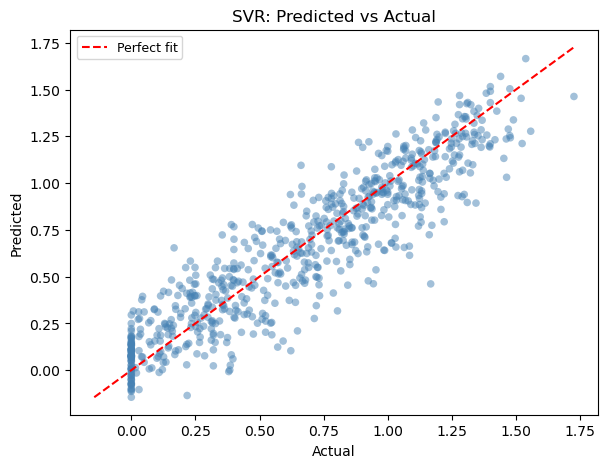

In [799]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
y_pred = svr.predict(x_test_scaled)
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])

ax1.scatter(y_test,y_pred,alpha=0.5,color='steelblue',edgecolors='none',s=30)

mn = min(y_test.min(), y_pred.min())
mx = max(y_test.max(), y_pred.max())

ax1.plot(
    [mn, mx],
    [mn, mx],
    'r--',
    linewidth=1.5,
    label='Perfect fit'
)

# Labels
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title('SVR: Predicted vs Actual')

ax1.legend(fontsize=9)

plt.show()

In [800]:
# pip install xgboost

In [801]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=400,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

model(xgb_model, x_train_scaled, y_train, x_test_scaled, y_test)

R-squared: 0.8710
Mean Squared Error: 0.0247
Mean Squared Error (Training): 0.0195


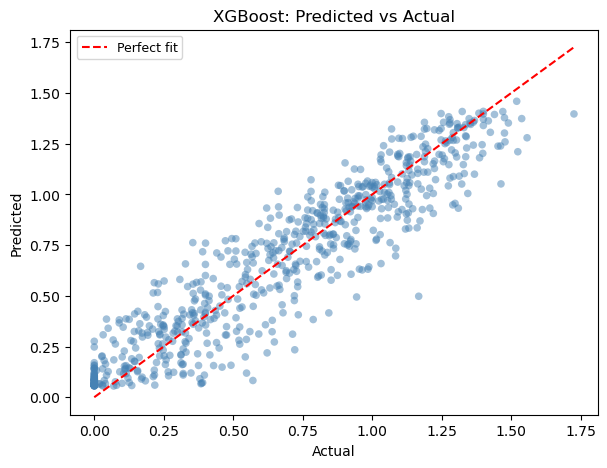

In [802]:
import matplotlib.gridspec as gridspec
y_pred = xgb_model.predict(x_test_scaled)
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none', s=30)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax1.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title('XGBoost: Predicted vs Actual')
ax1.legend(fontsize=9)

## 7. Evaluation

In [ ]:
#evaluating

X=model_data.drop('vitamin_deficiency',axis=1)
y=model_data['vitamin_deficiency']

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGB": XGBRegressor(
    objective='reg:squarederror',
    n_estimators=400,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
),
 "SVR": SVR(kernel='rbf', C=0.2,epsilon=0.05, gamma='scale')
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    scores = []

    for train_idx, test_idx in kf.split(X):
        
        x_train, x_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)

        score = r2_score(y_test, y_pred)
        scores.append(score)

    results[name] = {
        "Mean R2": np.mean(scores),
        "Std R2": np.std(scores)
    }



In [804]:
for name, result in results.items():
    print(f"{name}:")
    print(f"  Mean R2: {result['Mean R2']:.4f}")
    print(f"  Std R2: {result['Std R2']:.4f}")
    print("-" * 30)

Linear Regression:
  Mean R2: 0.7844
  Std R2: 0.0136
------------------------------
Random Forest:
  Mean R2: 0.8768
  Std R2: 0.0125
------------------------------
XGB:
  Mean R2: 0.8849
  Std R2: 0.0109
------------------------------
SVR:
  Mean R2: 0.8773
  Std R2: 0.0088
------------------------------


## 8. Exploratory Data Analysis (EDA)

In [805]:
df_preprocessed.head()

,gender,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,vitamin_a_percent_rda,vitamin_c_percent_rda,...,vitamin_e_percent_rda,vitamin_b12_percent_rda,folate_percent_rda,calcium_percent_rda,iron_percent_rda,symptoms_count,symptoms_list,vitamin_deficiency,bmi_category,age_group
0,1,1,1,0,3,0,0,2,119.1,147.3,...,97.5,102.5,188.9,108.3,97.4,0,0,0.0000,0,1
1,0,1,2,1,0,1,1,1,85.7,57.5,...,82.7,62.6,51.0,42.6,102.5,1,1,0.8440,1,1
2,1,1,0,2,0,1,0,0,48.3,152.1,...,169.3,136.2,116.6,136.3,86.4,2,1,0.0040,2,2
3,1,2,0,2,3,0,1,1,75.8,51.0,...,85.7,31.8,66.5,76.5,60.8,2,1,0.7724,0,1
4,1,2,1,2,3,2,0,1,93.3,111.5,...,155.6,72.6,124.9,69.4,71.9,0,0,0.3720,2,1


In [806]:
numeric_preprocessed = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_preprocessed = df_preprocessed.select_dtypes(include=['object']).columns.tolist()
print(categorical_preprocessed)

[]


### The numeric column 

In [807]:
hist_cols = numeric_cols.copy()
hist_cols.remove('symptoms_count')
numeric_cols

['vitamin_a_percent_rda',
 'vitamin_c_percent_rda',
 'vitamin_d_percent_rda',
 'vitamin_e_percent_rda',
 'vitamin_b12_percent_rda',
 'folate_percent_rda',
 'calcium_percent_rda',
 'iron_percent_rda',
 'symptoms_count',
 'vitamin_deficiency']

In [808]:
cols_per_row = 4
num_rows = math.ceil(len(hist_cols) / cols_per_row)
print(f"Number of numeric columns to plot: {len(hist_cols)}")
print(f"Number of rows needed: {num_rows}")

Number of numeric columns to plot: 9
Number of rows needed: 3


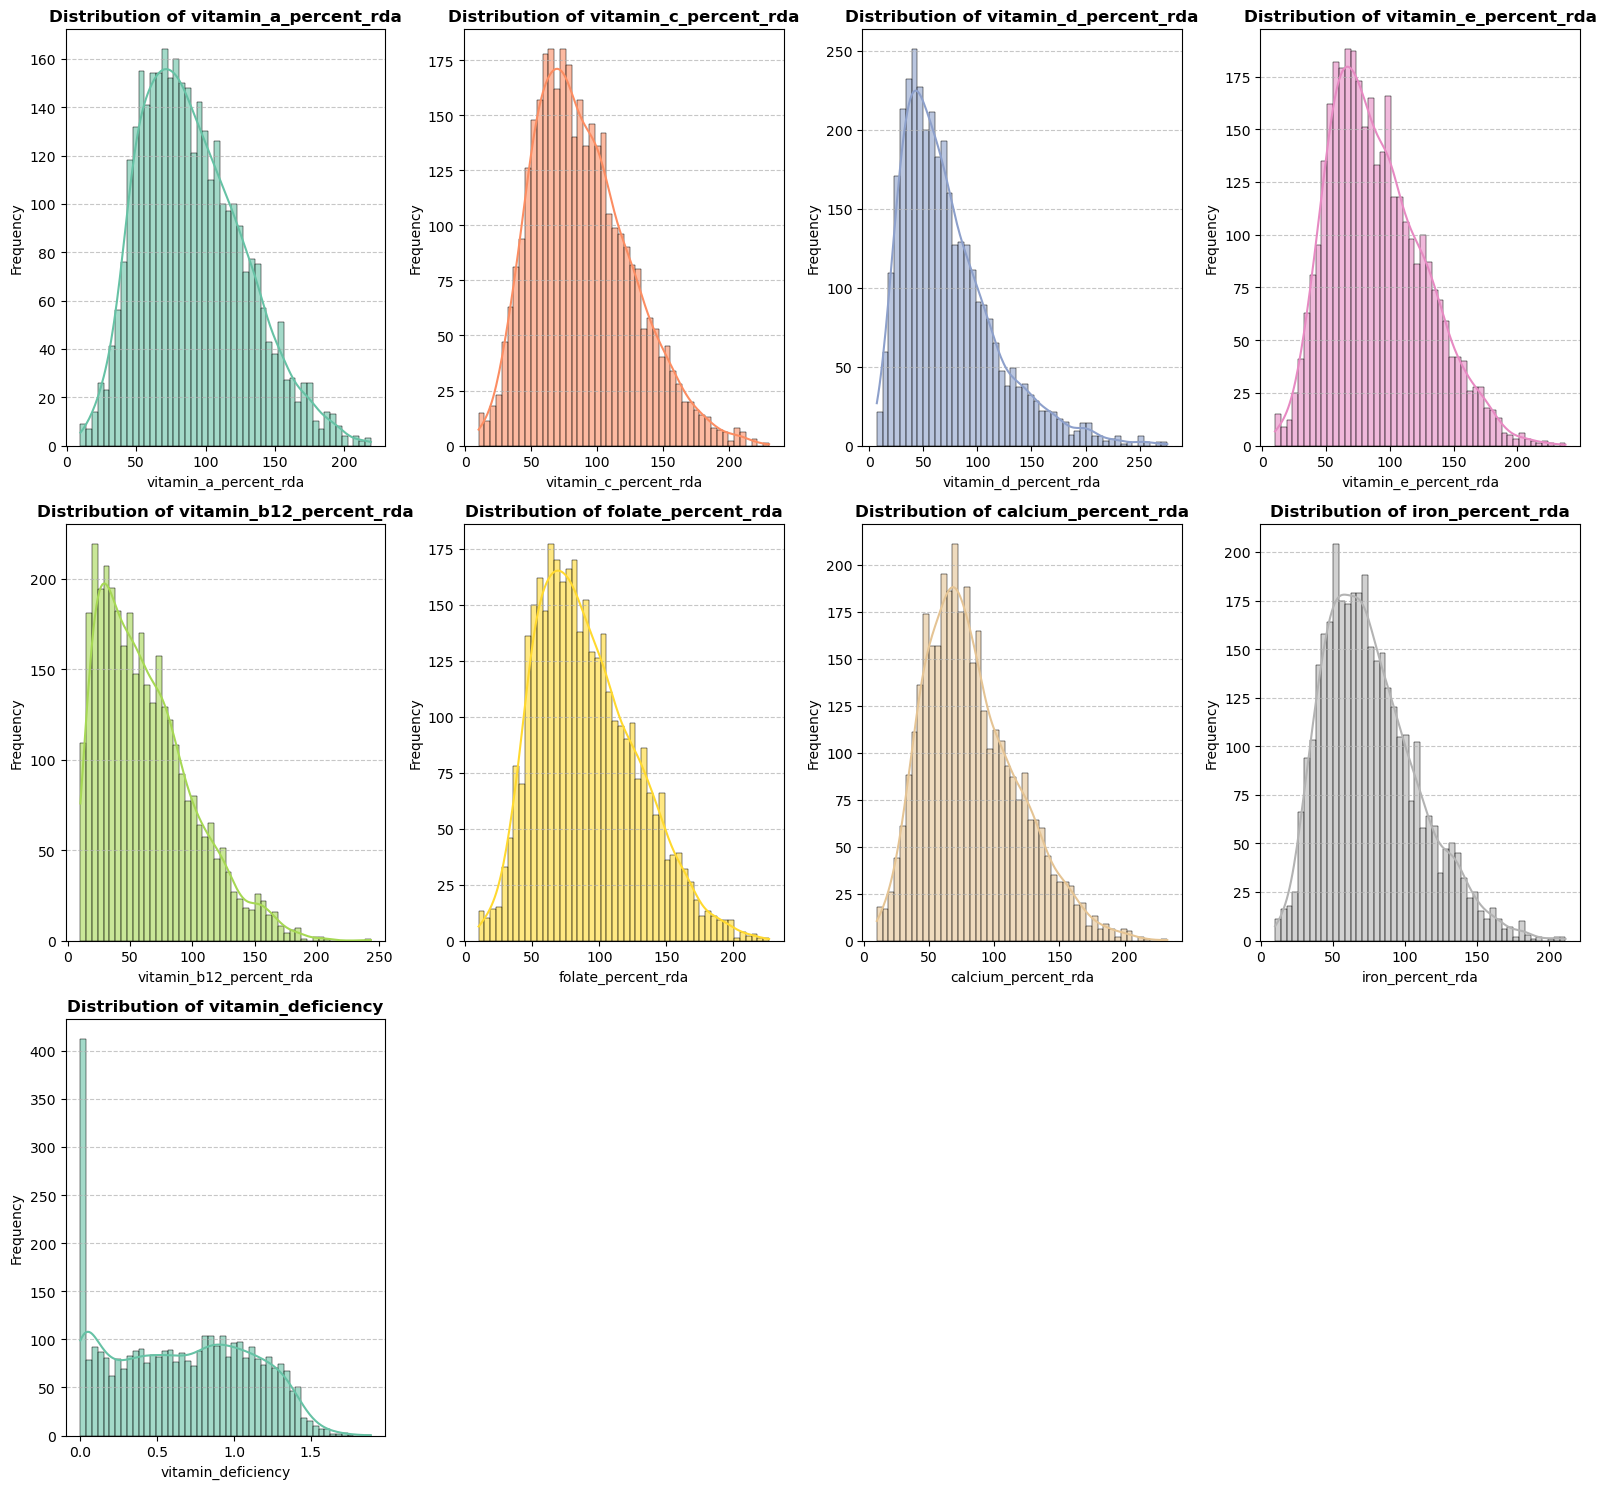

In [809]:
fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(16, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    sns.histplot(data=df, x=col,kde=True,bins=50, alpha=0.6, color=sns.color_palette("Set2")[i % 8], ax=axes[i])        
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(hist_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

plt.show()

In [810]:
scatter_cols = numeric_cols.copy()
scatter_cols.remove("vitamin_deficiency")

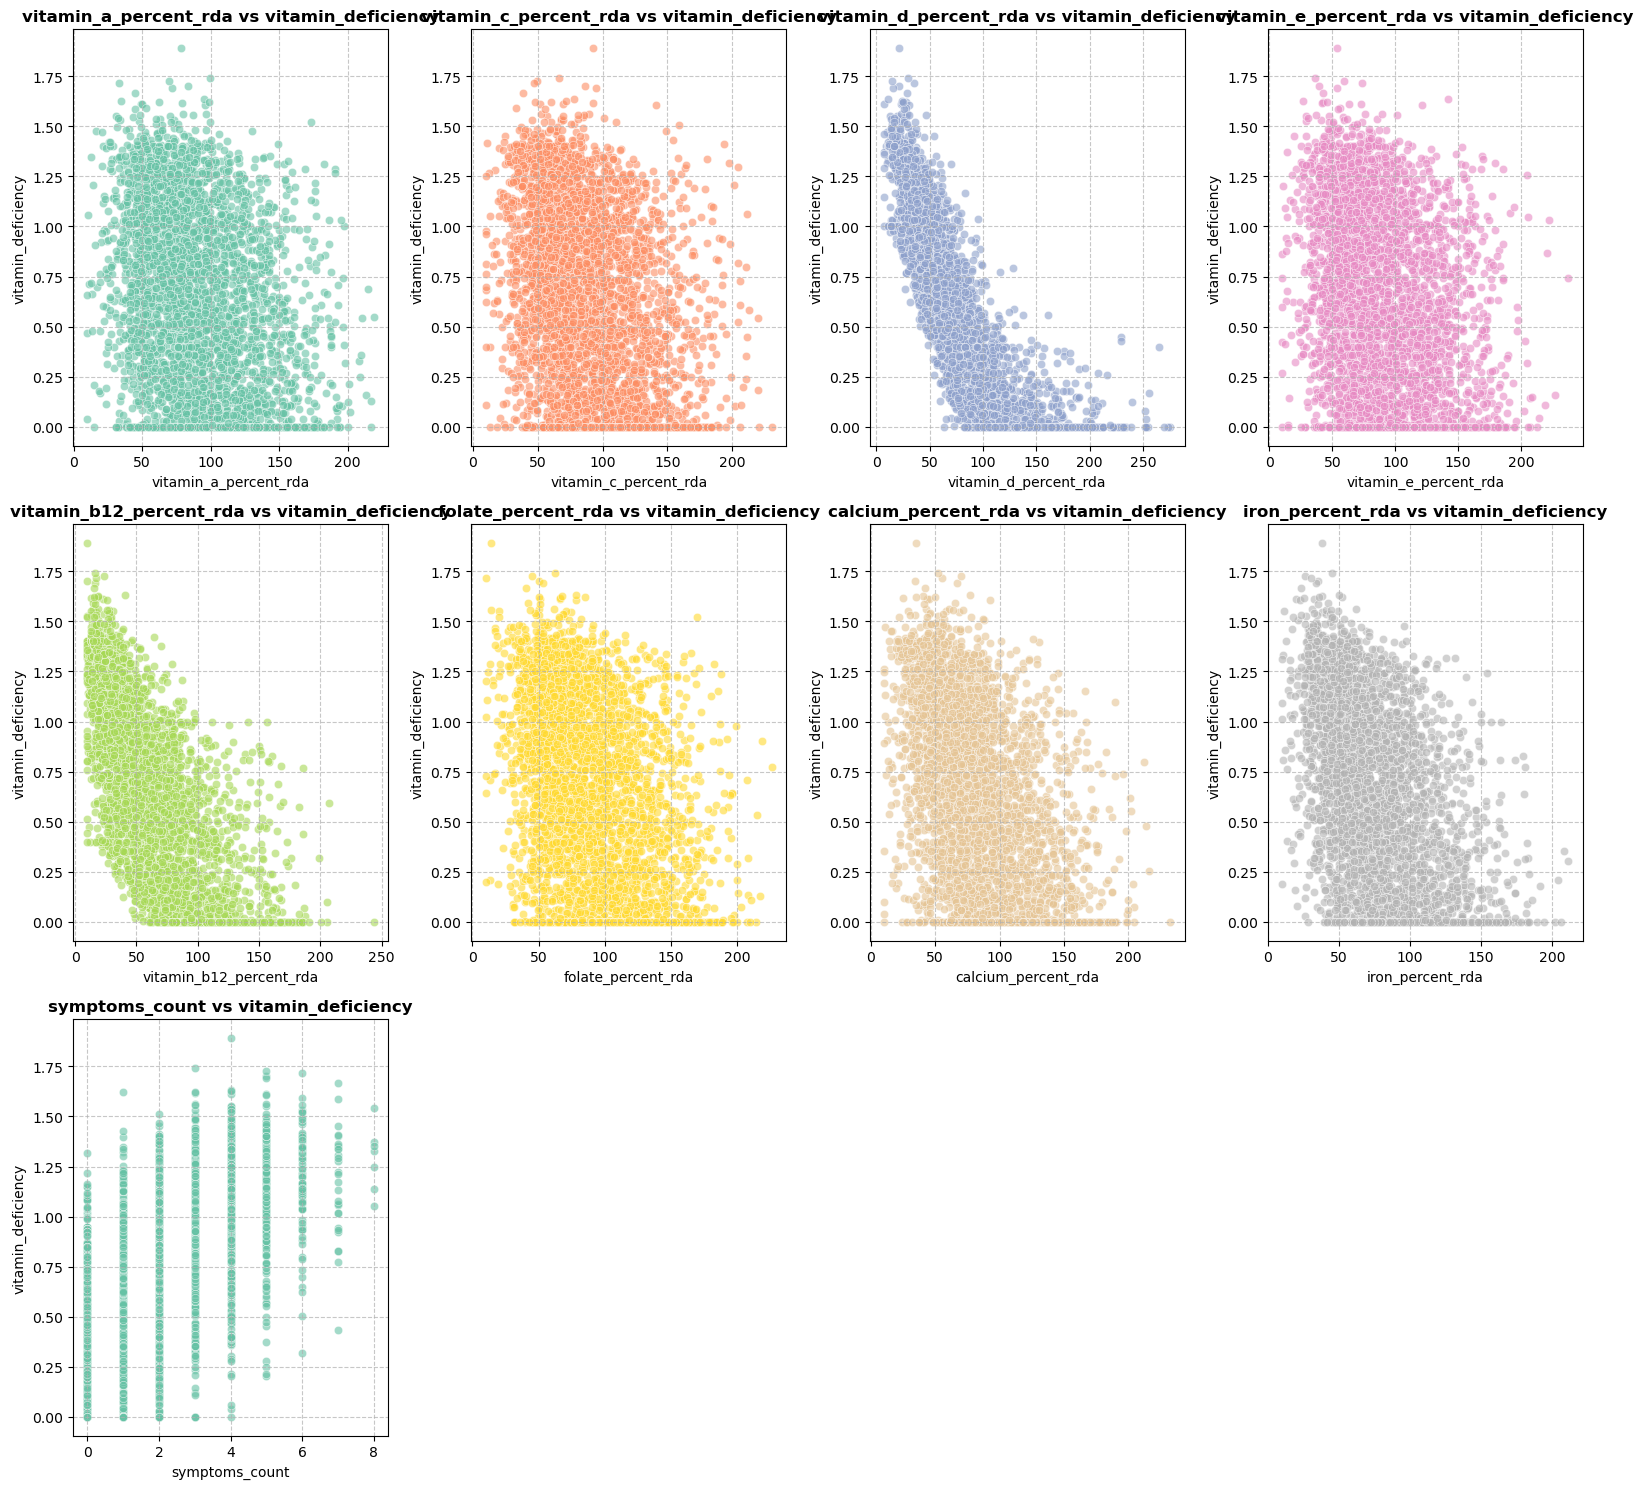

In [811]:
fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(16, 5 * num_rows))
axes = axes.flatten()
target_col = 'vitamin_deficiency'
for i, col in enumerate(scatter_cols):
    sns.scatterplot(data=df, x=col, y=target_col, alpha=0.6, color=sns.color_palette("Set2")[i % 8], ax=axes[i])
    axes[i].set_title(f'{col} vs {target_col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel(target_col, fontsize=10)
    axes[i].grid(linestyle='--', alpha=0.7)

for j in range(len(scatter_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- vitamin_b12_percent_rda
- iron_percent_rda 
- symptoms_count
- vitamin_d_percent_rda

In [812]:
box_cols = numeric_cols.copy()
#box_cols.remove("vitamin_deficiency")

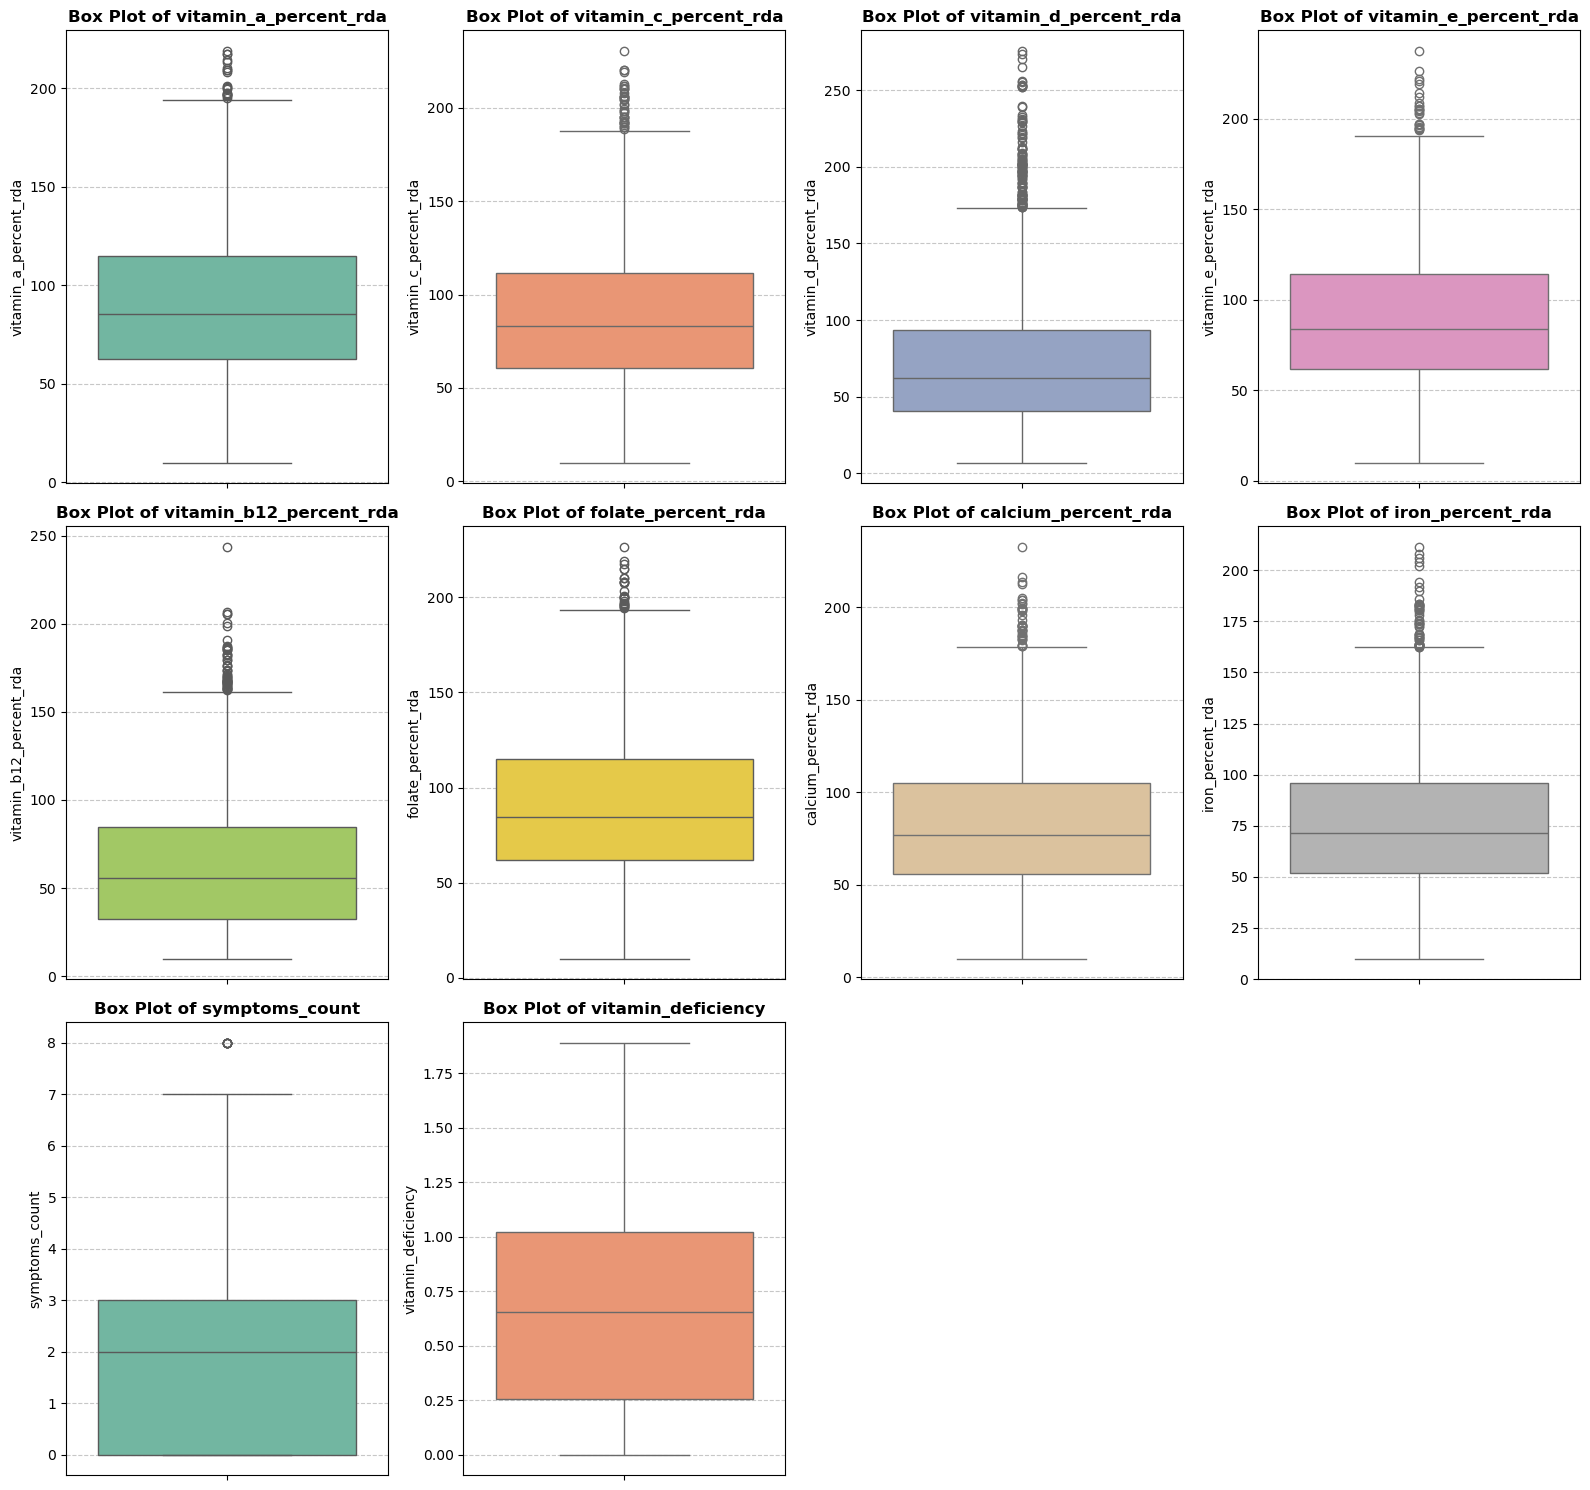

In [813]:
fig, axes = plt.subplots(nrows=num_rows, ncols=cols_per_row, figsize=(16, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(data=df, y=col, color=sns.color_palette("Set2")[i % 8], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

for j in range(len(box_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical Column Analysis

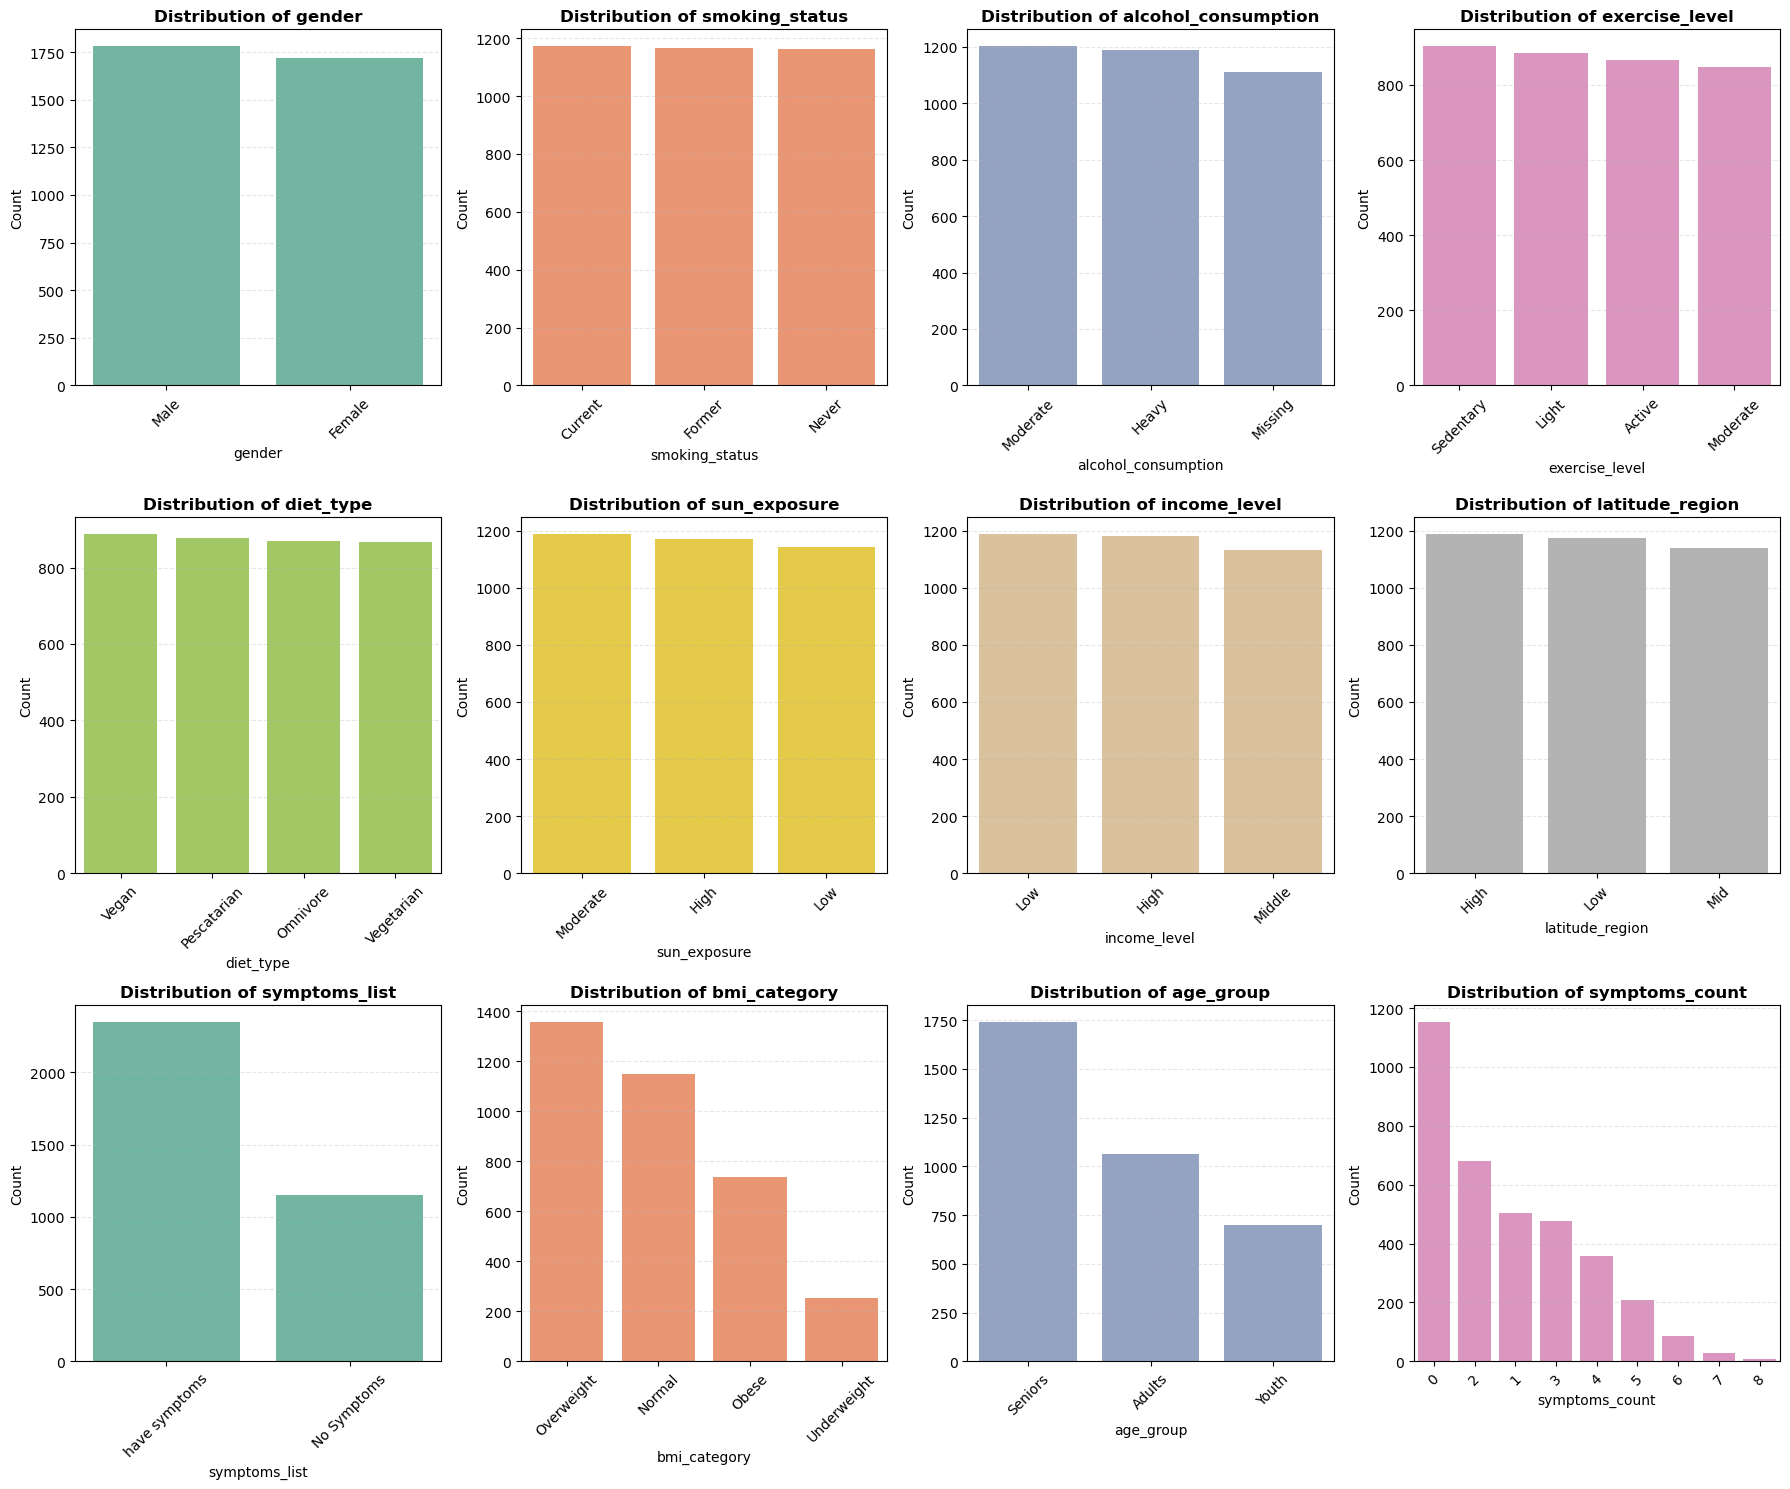

In [814]:
cols_per_row = 4
num_rows = math.ceil(len(count_plot_cols) / cols_per_row)

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=cols_per_row,
    figsize=(18, 5 * num_rows)
)
axes = np.array(axes).reshape(-1)

for i, col in enumerate(count_plot_cols):
    ax = axes[i]
    series = df[col]

    if series.nunique() > 15:
        top_values = series.value_counts().nlargest(15).index
        series = series.where(series.isin(top_values), "Other")

    order = series.value_counts().index
    sns.countplot(x=series, order=order, ax=ax, color=sns.color_palette("Set2")[i % 8])

    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

for j in range(len(count_plot_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Target Analysis 

In [815]:
corr_matrix = df[numeric_cols].corr()



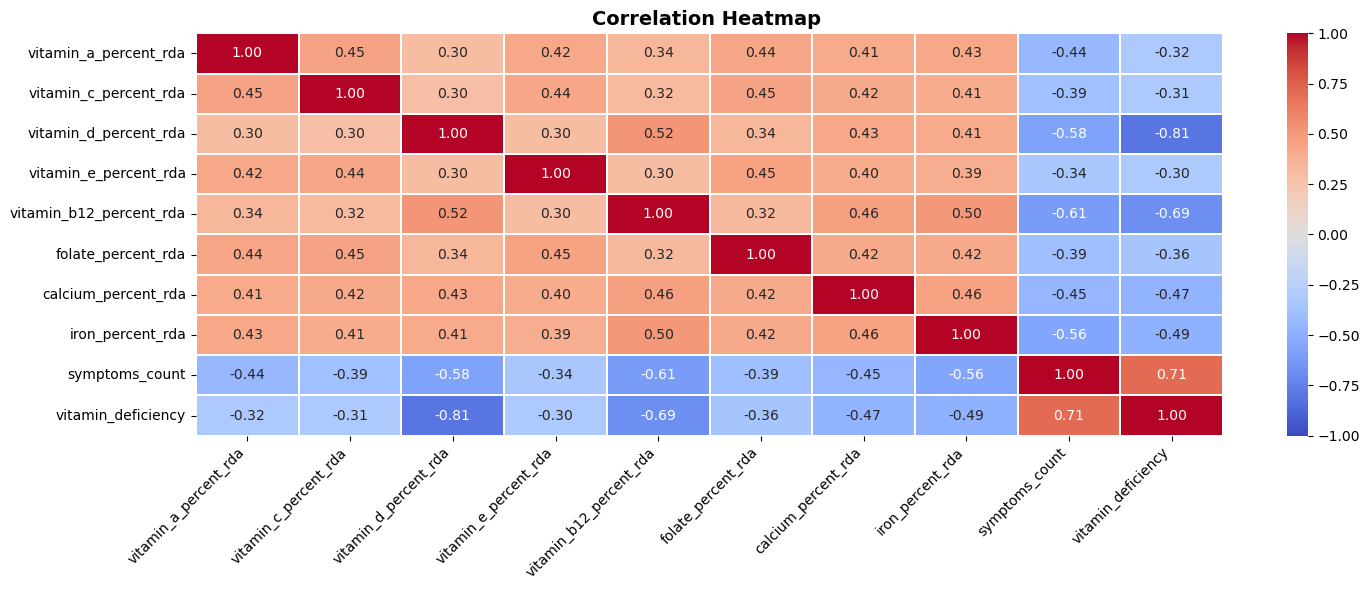

In [816]:
plt.figure(figsize=(15, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f", cmap='coolwarm', linewidths=0.1,
    vmin=-1, vmax=1,
    linecolor='white'
)

plt.title('Correlation Heatmap ', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [817]:
# f_scores, p_values = f_regression(df_preprocessed[Encoded_columns], df_preprocessed['vitamin_deficiency'])
print(x_train.columns.tolist())  
Encoded_columns = [c for c in x_train.columns if c in 
                   ['gender', 'smoking_status', 'alcohol_consumption', 
                    'exercise_level', 'latitude_region', 'diet_type',
                    'symptoms_list', 'bmi_category', 'age_group']]

f_scores, p_values = f_regression(x_train[Encoded_columns], y_train)

['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'symptoms_count', 'symptoms_list', 'bmi_category', 'age_group']


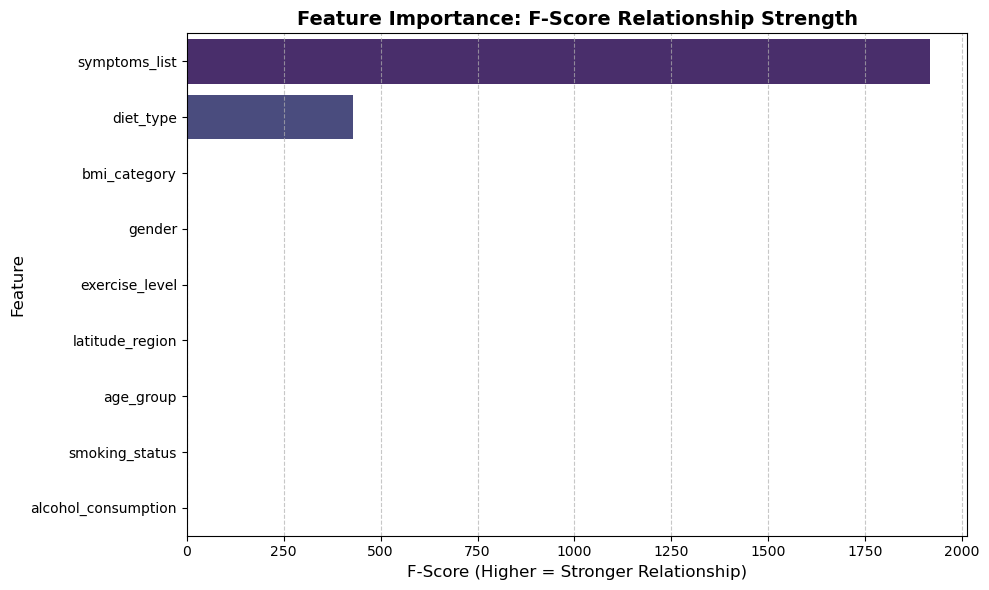


Statistically Significant Features (p < 0.05):
         Feature      F_Score        P_Value
6  symptoms_list  1917.492501  1.775178e-319
4      diet_type   428.680270   1.014326e-88


In [818]:
importance_df = pd.DataFrame({
    'Feature': Encoded_columns,
    'F_Score': f_scores,
    'P_Value': p_values
})

plt.figure(figsize=(10, 6))
sns.barplot(
    x='F_Score', 
    y='Feature', 
    data=importance_df.sort_values(by='F_Score', ascending=False), 
    palette='viridis'
)
plt.title('Feature Importance: F-Score Relationship Strength', fontsize=14, fontweight='bold')
plt.xlabel('F-Score (Higher = Stronger Relationship)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

features = importance_df[importance_df['P_Value'] < 0.05].sort_values(by='F_Score', ascending=False)
print("\nStatistically Significant Features (p < 0.05):")
print(features)

In [819]:
# data = df_preprocessed[['vitamin_b12_percent_rda' ,'iron_percent_rda', 'symptoms_count', 'vitamin_d_percent_rda','vitamin_deficiency'] + features['Feature'].tolist()]

In [820]:
# x_train, x_test, y_train, y_test = train_test_split( data.drop("vitamin_deficiency", axis=1), model_data["vitamin_deficiency"],test_size=0.2,random_state=42
# )
# scaler = MinMaxScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [821]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
model(rf, x_train_scaled, y_train, x_test_scaled, y_test)

TypeError: 'SVR' object is not callable

In [ ]:
lr= LinearRegression()
model(lr, x_train_scaled, y_train, x_test_scaled, y_test)   

R-squared: 0.8509
Mean Squared Error: 0.0285
Mean Squared Error (Training): 0.0270
